In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_squared_error, r2_score



In [ ]:
df=pd.read_csv("/content/finance_economics_dataset.csv")
df.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


In [ ]:
df.describe()

,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),Interest Rate (%),Consumer Confidence Index,...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
count,3000.000000,3000.000000,3000.000000,3000.00000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2982.094607,2981.249173,3018.887777,2944.32975,5.033864e+08,2.608903,5.096830,8.663787,5.218237,85.036000,...,1.146113,115.115233,85.539953,1655.167877,300.554457,5099.546667,5.007413,24.598667,49.955197,7551.278000
std,1151.862689,1151.783841,1151.683485,1151.83490,2.859004e+08,4.287337,2.910513,3.737536,2.726115,20.224829,...,0.201128,20.111351,37.847063,492.177706,114.601328,2898.714108,2.866466,14.301344,28.722592,4203.705678
min,1000.050000,954.520000,1012.130000,917.17000,1.636024e+06,-5.000000,0.010000,2.000000,0.500000,50.000000,...,0.800000,80.010000,20.040000,800.160000,100.130000,107.000000,0.010000,0.000000,0.100000,101.000000
25%,1994.982500,1997.425000,2035.952500,1955.39750,2.545224e+08,-1.012500,2.607500,5.450000,2.890000,68.000000,...,0.980000,98.267500,52.590000,1226.737500,202.370000,2503.750000,2.570000,12.000000,25.762500,3950.750000
50%,2970.780000,2977.180000,3006.520000,2939.24500,5.033710e+08,2.725000,5.110000,8.710000,5.250000,86.000000,...,1.140000,114.795000,85.080000,1666.060000,299.885000,5123.500000,5.060000,25.000000,49.840000,7610.000000
75%,3974.690000,3982.082500,4015.217500,3934.08750,7.537963e+08,6.242500,7.600000,11.882500,7.492500,103.000000,...,1.320000,132.455000,119.150000,2080.730000,399.137500,7616.250000,7.482500,37.000000,74.825000,11148.750000
max,4998.230000,5034.130000,5076.190000,4977.06000,9.999771e+08,10.000000,10.000000,15.000000,10.000000,119.000000,...,1.500000,149.960000,149.870000,2499.660000,499.920000,9998.000000,10.000000,49.000000,99.990000,14990.000000


In [ ]:
df.shape

(3000, 24)

In [ ]:
# Check for null values
df.isnull().sum()

,0
Date,0
Stock Index,0
Open Price,0
Close Price,0
Daily High,0
Daily Low,0
Trading Volume,0
GDP Growth (%),0
Inflation Rate (%),0
Unemployment Rate (%),0


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes


,0
Date,object
Stock Index,object
Open Price,float64
Close Price,float64
Daily High,float64
Daily Low,float64
Trading Volume,int64
GDP Growth (%),float64
Inflation Rate (%),float64
Unemployment Rate (%),float64


EDA

In [ ]:
# Label encode the Stock Index column
le = LabelEncoder()
df['Stock Index Encoded'] = le.fit_transform(df['Stock Index'])

# Check the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Encoding mapping:', mapping)

df[['Stock Index', 'Stock Index Encoded']].head(10)

Encoding mapping: {'Dow Jones': np.int64(0), 'NASDAQ': np.int64(1), 'S&P 500': np.int64(2)}


,Stock Index,Stock Index Encoded
0,Dow Jones,0
1,S&P 500,2
2,Dow Jones,0
3,Dow Jones,0
4,S&P 500,2
5,S&P 500,2
6,Dow Jones,0
7,NASDAQ,1
8,Dow Jones,0
9,Dow Jones,0


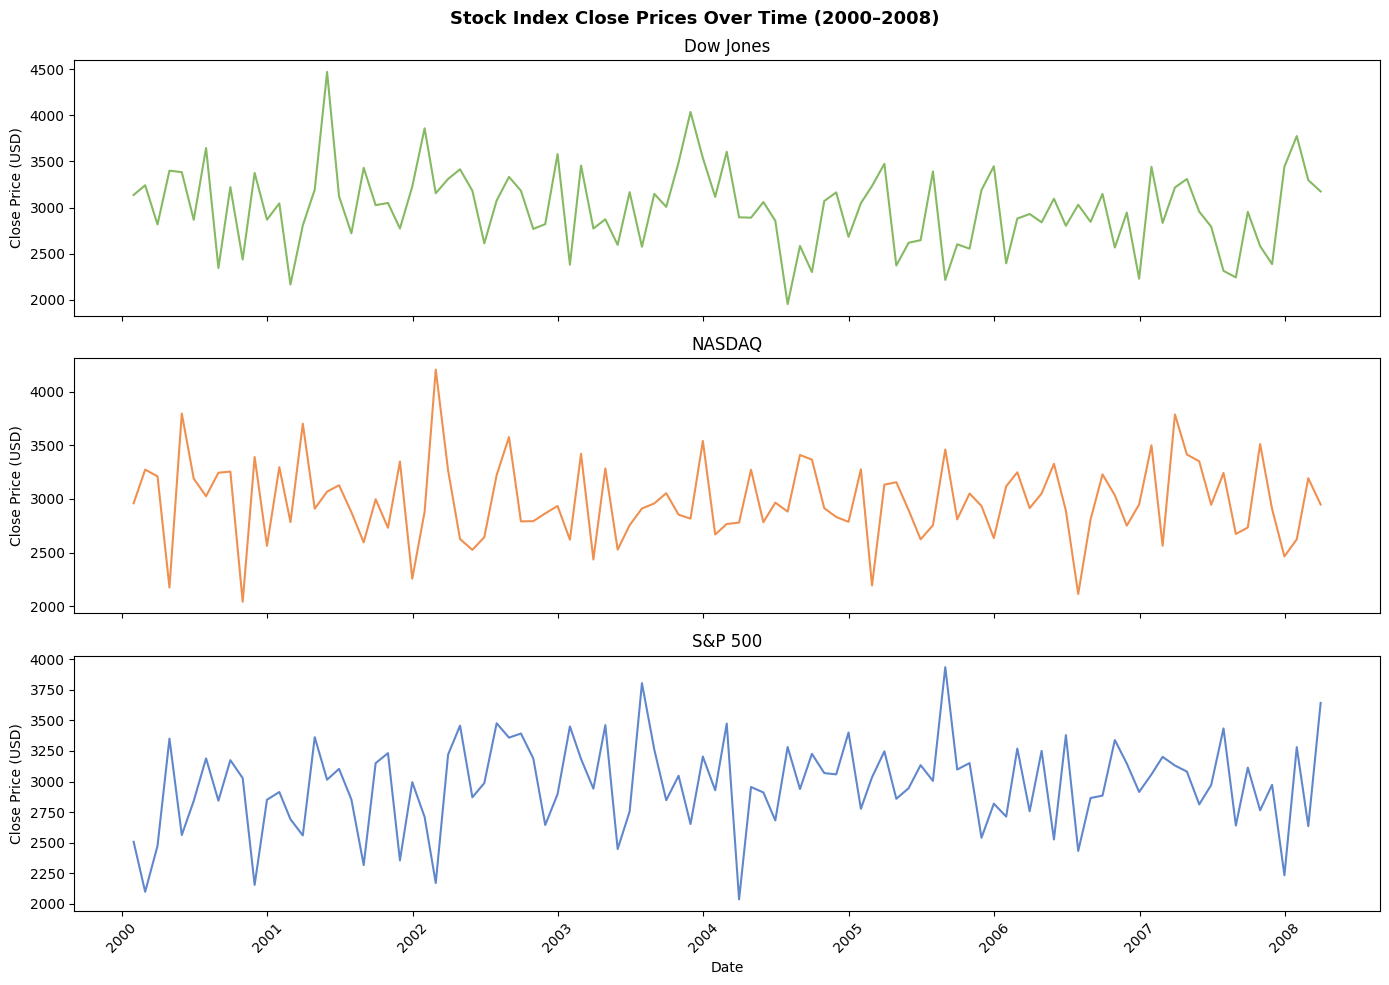

In [ ]:
import matplotlib.dates as mdates

df['Date'] = pd.to_datetime(df['Date'])

# Resample each index to monthly averages
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {'S&P 500': '#4472C4', 'NASDAQ': '#ED7D31', 'Dow Jones': '#70AD47'}

for ax, (index, group) in zip(axes, df.groupby('Stock Index')):
    # Smooth to monthly averages
    group = group.set_index('Date')
    group_monthly = group[['Close Price']].resample('ME').mean().reset_index()

    ax.plot(group_monthly['Date'], group_monthly['Close Price'],
            color=colors[index], linewidth=1.5, alpha=0.85)
    ax.set_title(index)
    ax.set_ylabel('Close Price (USD)')

# X axis on bottom subplot only
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.suptitle('Stock Index Close Prices Over Time (2000–2008)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

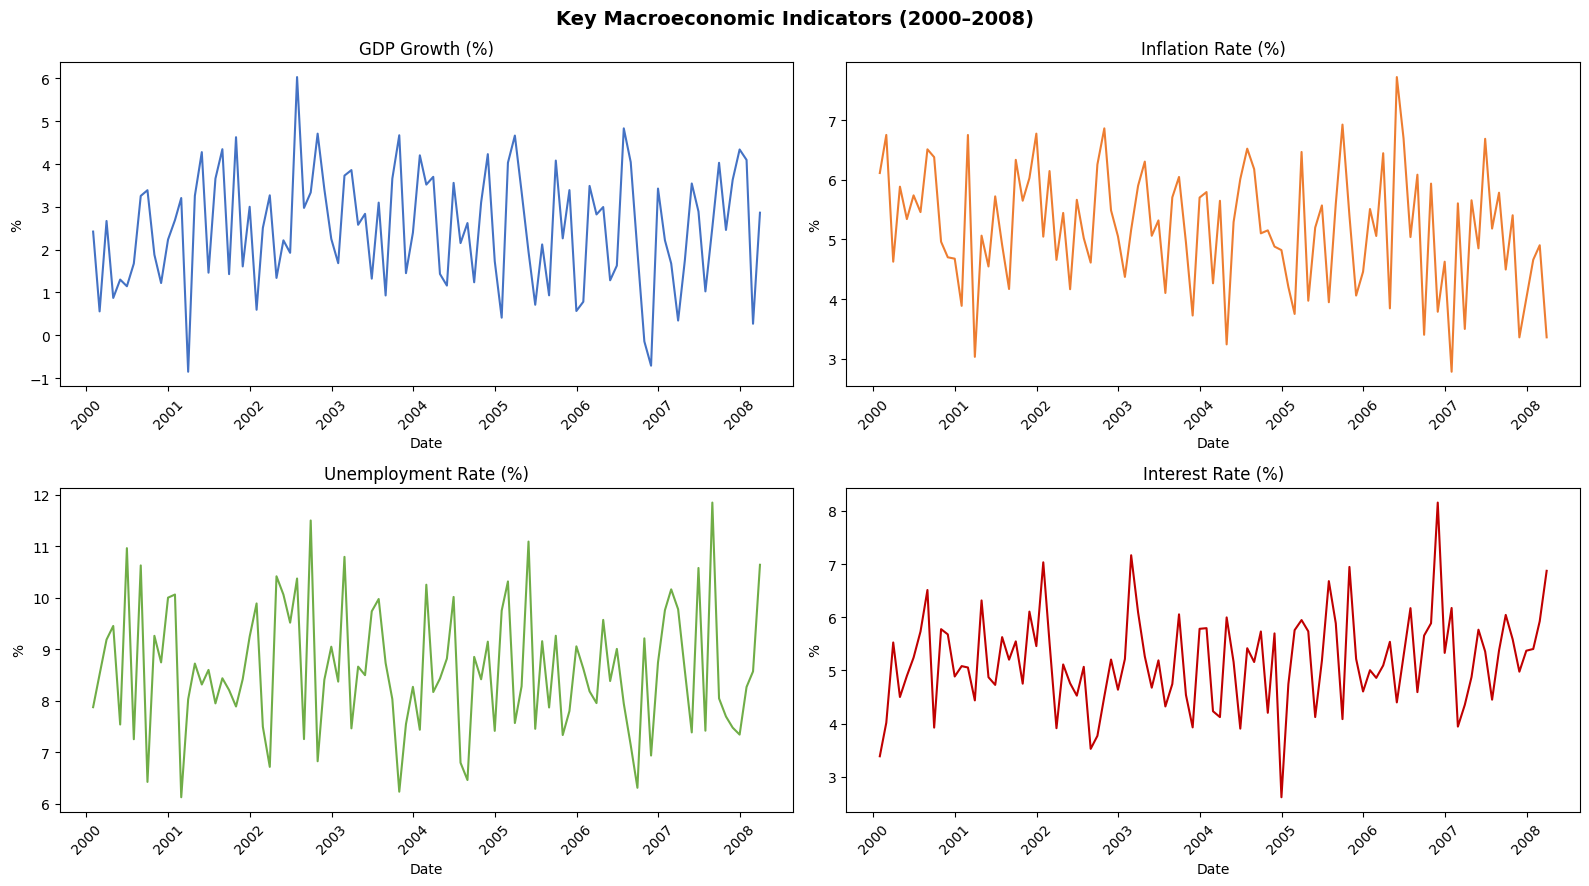

In [ ]:
macro = df[df['Stock Index'] == 'S&P 500'].copy()
macro = macro.set_index('Date')

# Select only numeric columns before resampling and calculating the mean
macro_numeric = macro.select_dtypes(include=np.number)
macro_monthly = macro_numeric.resample('ME').mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

macro_indicators = {
    'GDP Growth (%)': '#4472C4',
    'Inflation Rate (%)': '#ED7D31',
    'Unemployment Rate (%)': '#70AD47',
    'Interest Rate (%)': '#C00000'
}

for i, (col, color) in enumerate(macro_indicators.items()):
    axes[i].plot(macro_monthly['Date'], macro_monthly[col],
                 color=color, linewidth=1.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('%')
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Key Macroeconomic Indicators (2000–2008)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

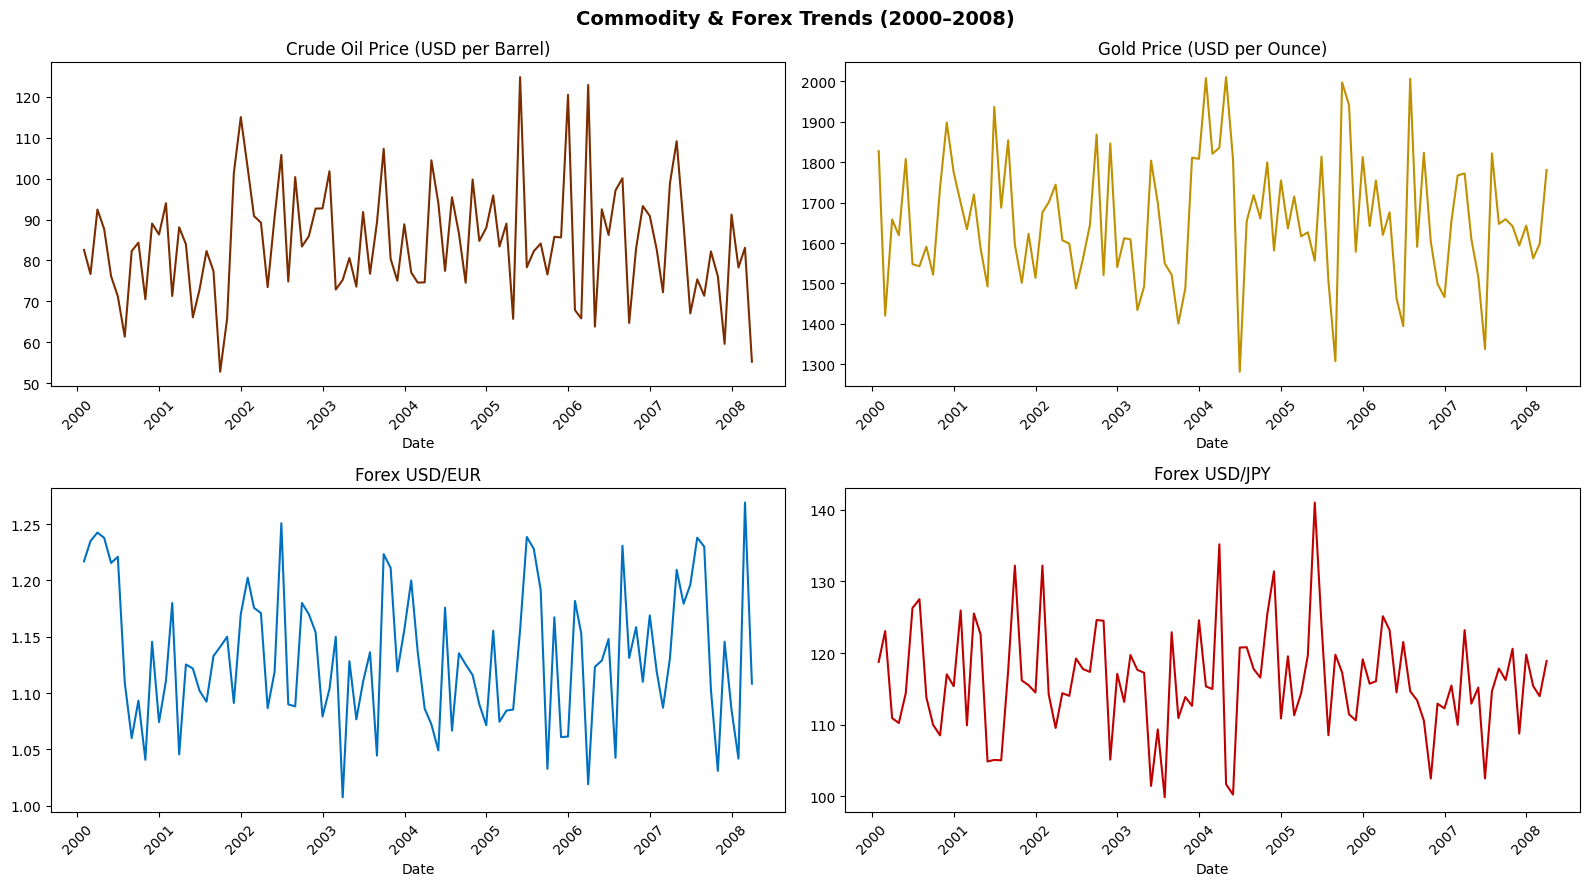

In [ ]:
# Resample to monthly averages
macro = df[df['Stock Index'] == 'S&P 500'].copy()
macro = macro.set_index('Date')

# Select only numeric columns before resampling and calculating the mean
macro_numeric = macro.select_dtypes(include=np.number)
macro_monthly = macro_numeric.resample('ME').mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

commodity_forex = {
    'Crude Oil Price (USD per Barrel)': '#7B2D00',
    'Gold Price (USD per Ounce)': '#BF9000',
    'Forex USD/EUR': '#0070C0',
    'Forex USD/JPY': '#C00000'
}

for i, (col, color) in enumerate(commodity_forex.items()):
    axes[i].plot(macro_monthly['Date'], macro_monthly[col],
                 color=color, linewidth=1.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('Date')
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Commodity & Forex Trends (2000–2008)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

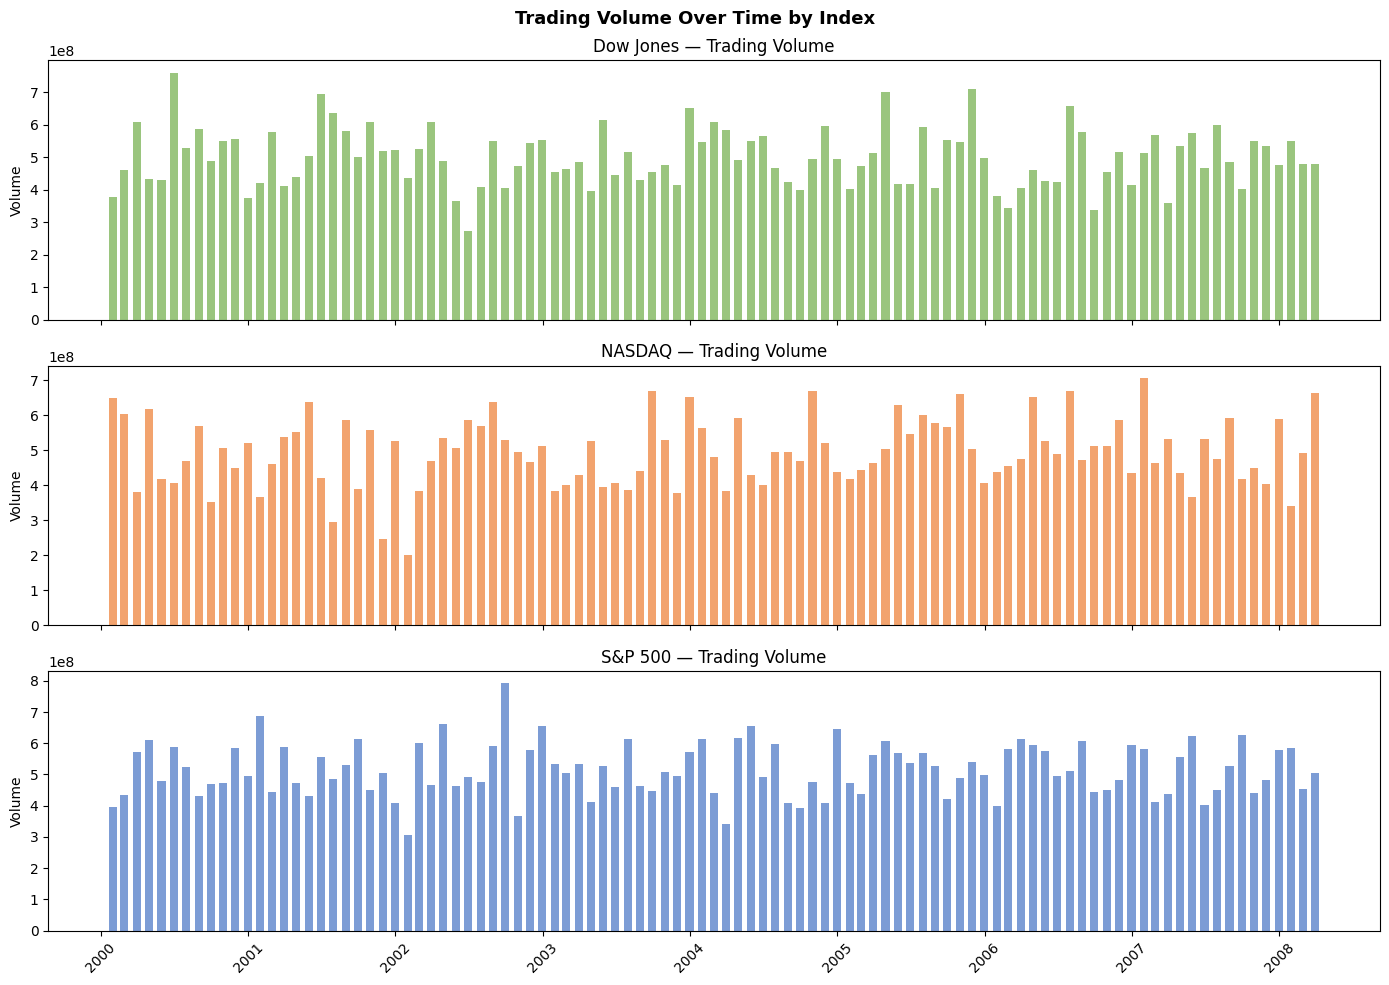

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Trading volume over time per index
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = {'S&P 500': '#4472C4', 'NASDAQ': '#ED7D31', 'Dow Jones': '#70AD47'}

for ax, (index, group) in zip(axes, df.groupby('Stock Index')):
    group = group.set_index('Date')
    group_monthly = group[['Trading Volume']].resample('ME').mean().reset_index()

    ax.bar(group_monthly['Date'], group_monthly['Trading Volume'],
           color=colors[index], alpha=0.7, width=20)
    ax.set_title(f'{index} — Trading Volume')
    ax.set_ylabel('Volume')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Trading Volume Over Time by Index',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

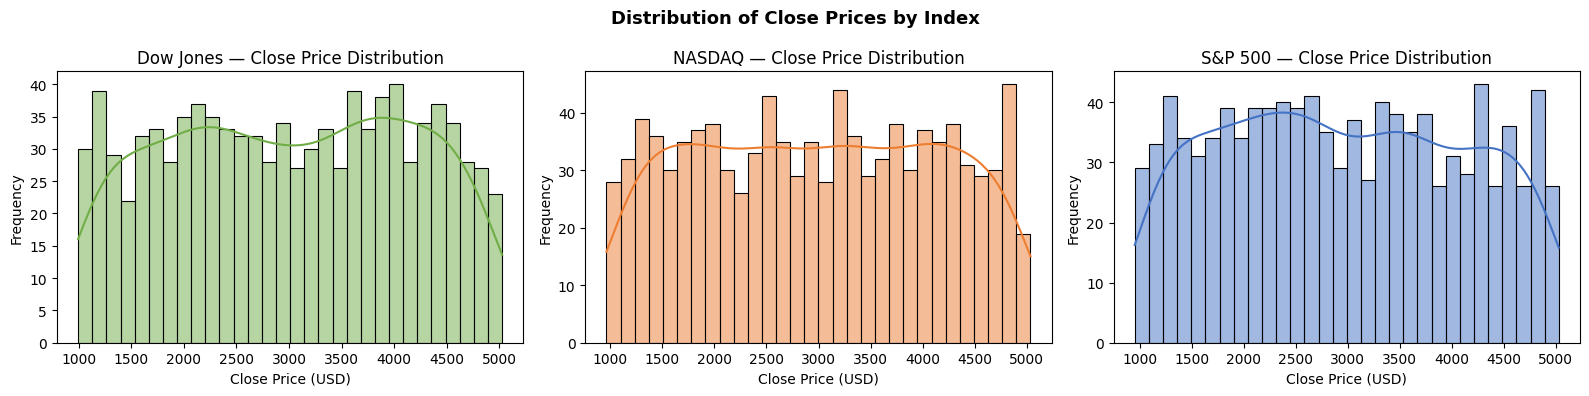

In [ ]:
# Distribution of close prices per index
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (index, group) in zip(axes, df.groupby('Stock Index')):
    sns.histplot(group['Close Price'], kde=True, ax=ax,
                 color=colors[index], bins=30)
    ax.set_title(f'{index} — Close Price Distribution')
    ax.set_xlabel('Close Price (USD)')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Close Prices by Index',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical summary per index
summary = df.groupby('Stock Index')[['Open Price', 'Close Price',
                                      'Daily High', 'Daily Low',
                                      'Trading Volume']].describe()
print(summary)

            Open Price                                                \
                 count         mean          std      min        25%   
Stock Index                                                            
Dow Jones        957.0  3004.943386  1146.435593  1007.97  2026.1200   
NASDAQ          1007.0  2987.015283  1157.127031  1000.91  1977.5000   
S&P 500         1036.0  2956.205222  1152.337023  1000.05  1967.8275   

                                          Close Price               ...  \
                  50%        75%      max       count         mean  ...   
Stock Index                                                         ...   
Dow Jones    3002.500  3995.3100  4995.57       957.0  3004.456447  ...   
NASDAQ       3000.230  4008.4450  4998.23      1007.0  2985.905015  ...   
S&P 500      2908.515  3936.9025  4990.51      1036.0  2955.286052  ...   

             Daily Low          Trading Volume                              \
                   75%      max       

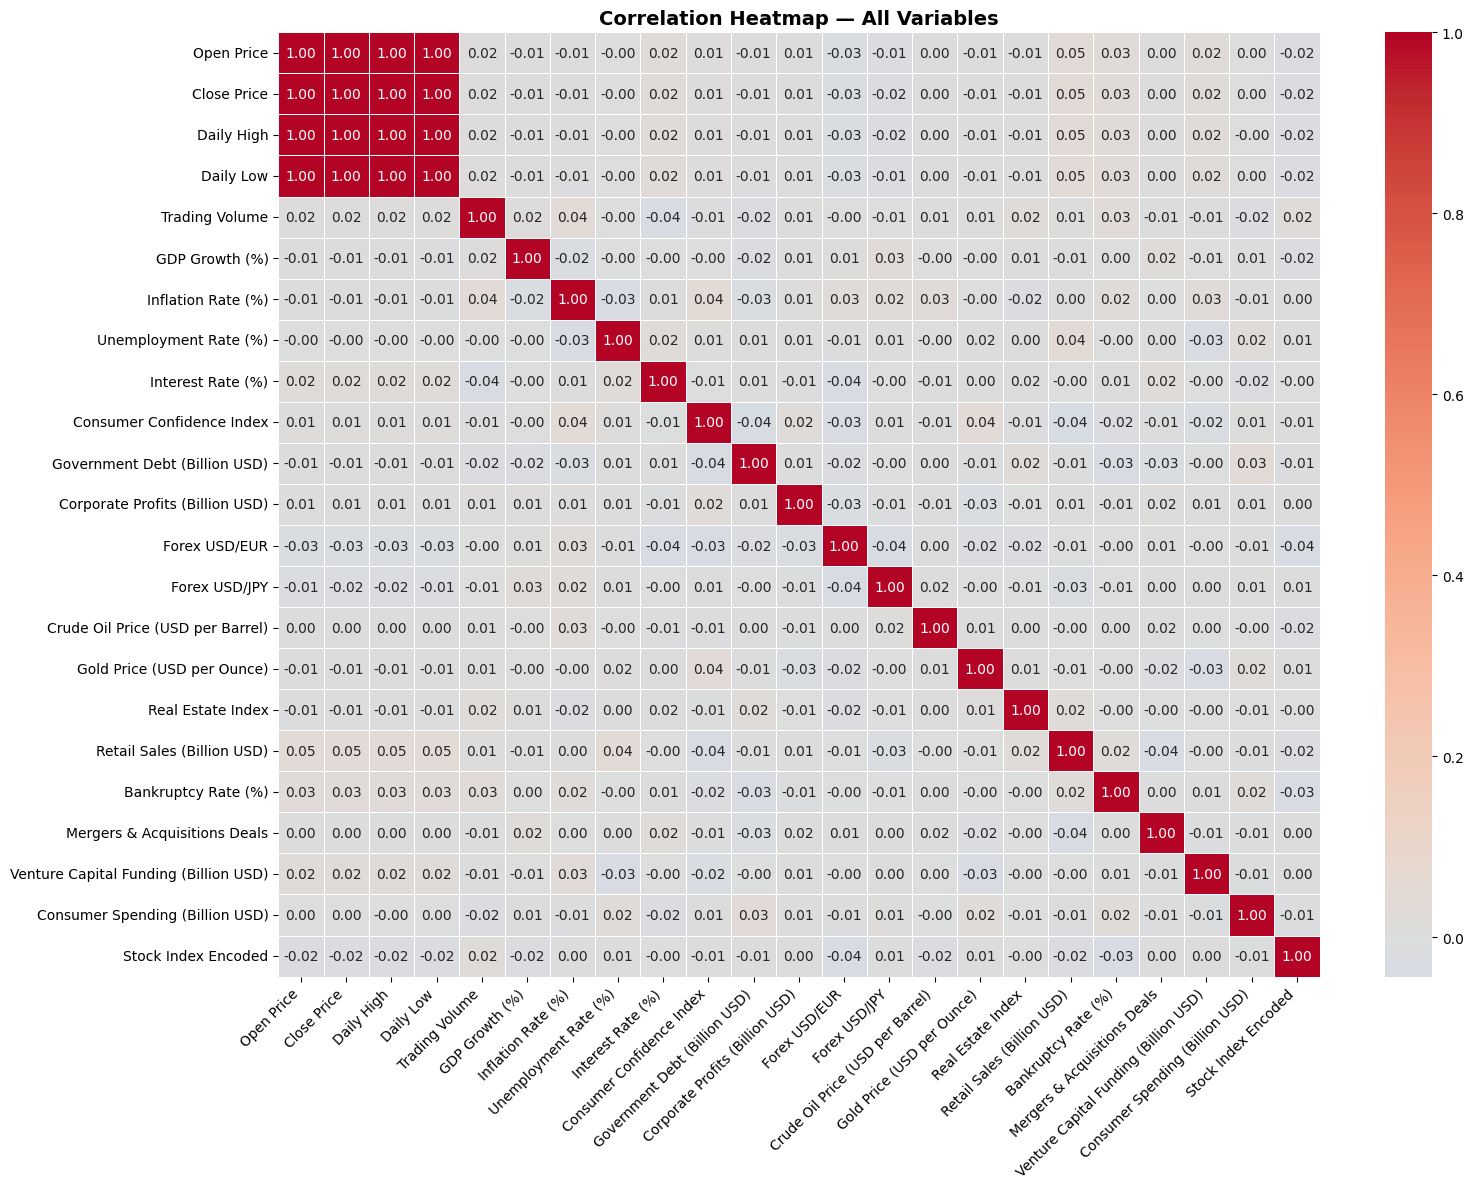

In [ ]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap — All Variables',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

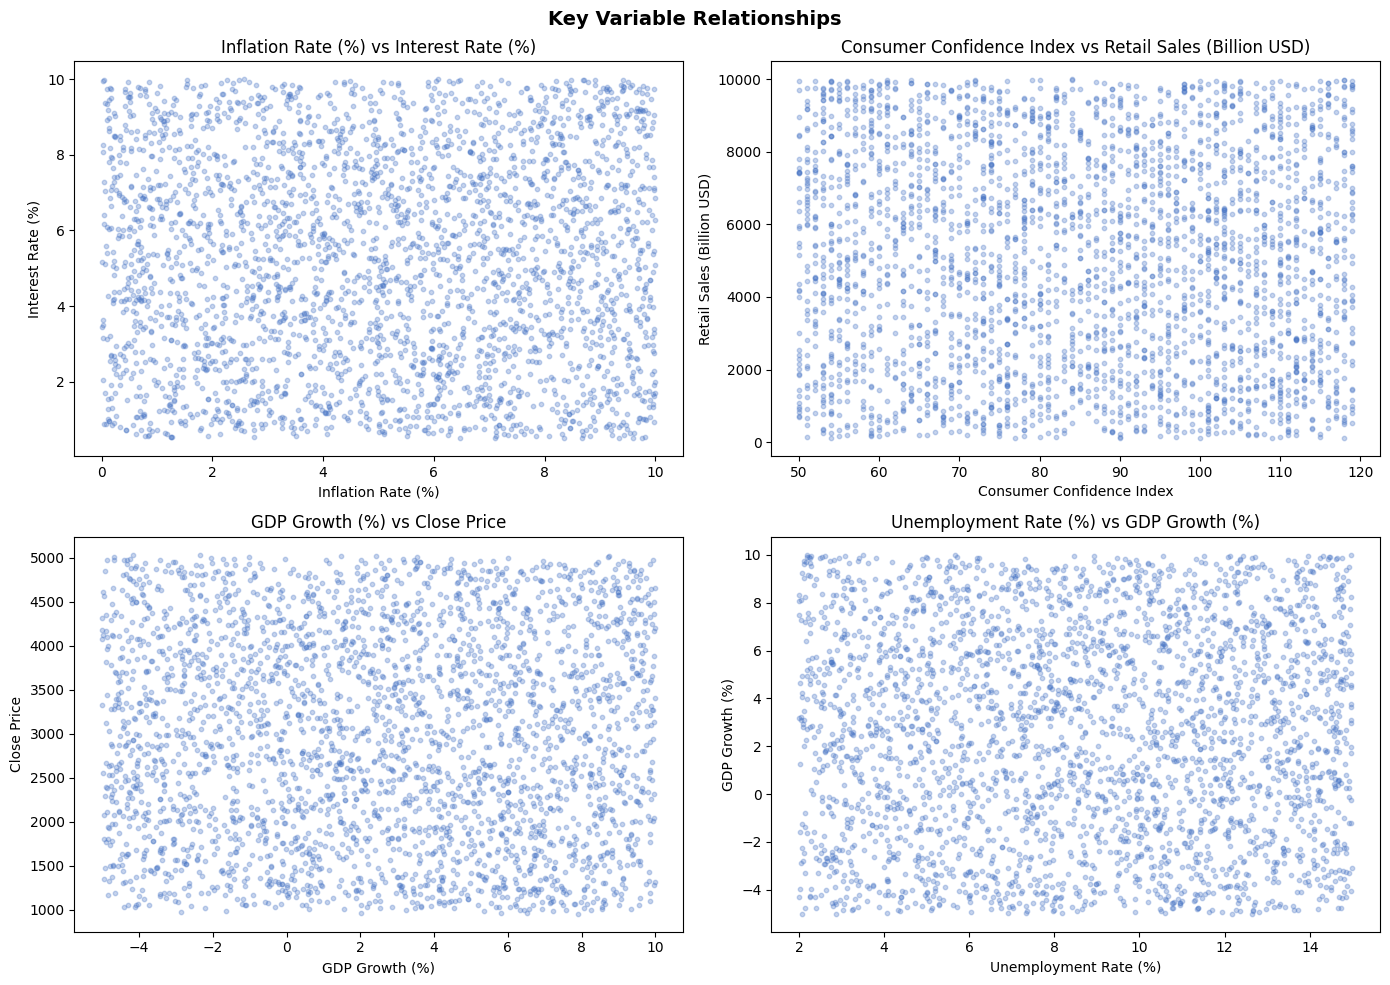

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Scatter plots for key variable pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pairs = [
    ('Inflation Rate (%)', 'Interest Rate (%)'),
    ('Consumer Confidence Index', 'Retail Sales (Billion USD)'),
    ('GDP Growth (%)', 'Close Price'),
    ('Unemployment Rate (%)', 'GDP Growth (%)')
]

for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.3, color='#4472C4', s=10)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')

plt.suptitle('Key Variable Relationships',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Select relevant features for anomaly detection
features = ['Close Price', 'Trading Volume', 'GDP Growth (%)',
            'Inflation Rate (%)', 'Unemployment Rate (%)',
            'Interest Rate (%)', 'Crude Oil Price (USD per Barrel)',
            'Gold Price (USD per Ounce)']

X = df[features].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05,
                              n_estimators=100,
                              random_state=42)
df['Anomaly'] = iso_forest.fit_predict(X_scaled)

# -1 = anomaly, 1 = normal
print('Normal points:', (df['Anomaly'] == 1).sum())
print('Anomalies detected:', (df['Anomaly'] == -1).sum())

Normal points: 2850
Anomalies detected: 150


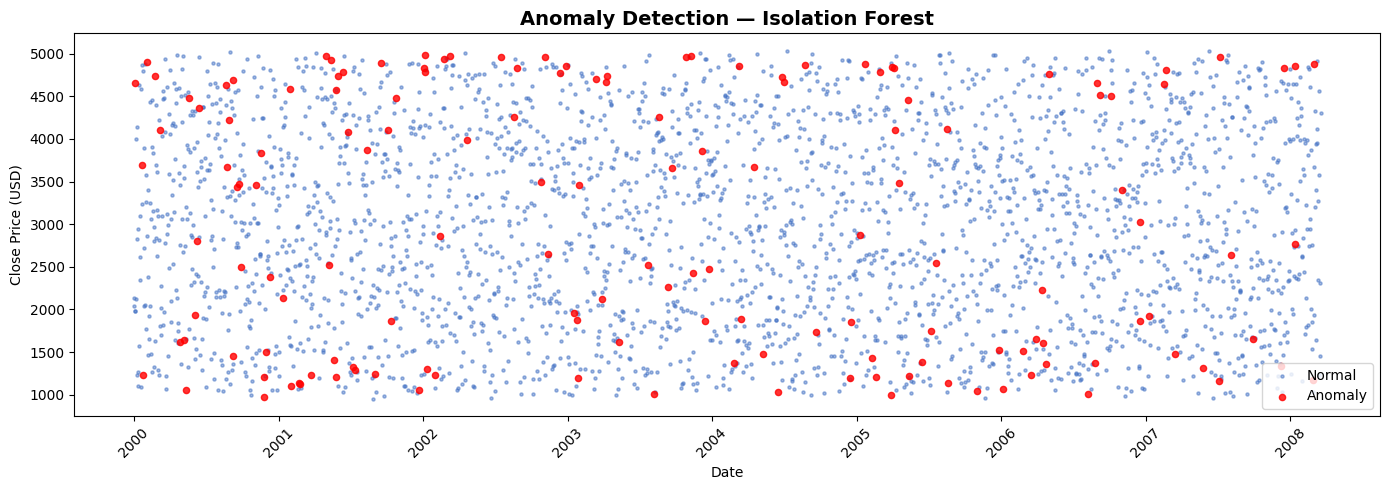

In [ ]:
# Visualize anomalies on a timeline
fig, ax = plt.subplots(figsize=(14, 5))

# Plot normal points
normal = df[df['Anomaly'] == 1]
ax.scatter(normal['Date'], normal['Close Price'],
           c='#4472C4', s=5, alpha=0.5, label='Normal')

# Plot anomalies
anomalies = df[df['Anomaly'] == -1]
ax.scatter(anomalies['Date'], anomalies['Close Price'],
           c='red', s=20, alpha=0.8, label='Anomaly')

ax.set_title('Anomaly Detection — Isolation Forest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
features = ['Open Price', 'Daily High', 'Daily Low',
            'Trading Volume', 'GDP Growth (%)',
            'Inflation Rate (%)', 'Unemployment Rate (%)',
            'Interest Rate (%)', 'Consumer Confidence Index',
            'Crude Oil Price (USD per Barrel)',
            'Gold Price (USD per Ounce)',
            'Stock Index Encoded']

target = 'Close Price'

X = df[features]
y = df[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (2400, 12)
Testing set: (600, 12)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print('Linear Regression Results:')
print(f'RMSE: {lr_rmse:.2f}')
print(f'R² Score: {lr_r2:.4f}')

Linear Regression Results:
RMSE: 16.31
R² Score: 0.9998


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100,
                                  random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'RMSE: {rf_rmse:.2f}')
print(f'R² Score: {rf_r2:.4f}')

Random Forest Results:
RMSE: 20.03
R² Score: 0.9997
